Import important packages

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Loading data and changing missing data values to Null

In [82]:
df = pd.read_csv("data/train.csv")
# Remove ? with NULL
df = df.replace(r"^\s*\?\s*$", pd.NA, regex=True)
# Remove Unkown/Invalid with NULL
df = df.replace(r"^\s*Unknown/Invalid\s*$", pd.NA, regex=True)
# Remove empty values with NULL
df = df.replace(r"^\s*$", pd.NA, regex=True)

#----------------------------------
#Setting unkown values from IDS_mapping to NULL in train.csv

# From IDS_mapping.csv
ids_to_null = {
    "admission_type_id": [5, 6, 8],                 # Not Available, NULL, Not Mapped
    "discharge_disposition_id": [18, 25, 26],       # NULL, Not Mapped, Unknown/Invalid
    "admission_source_id": [9, 15, 17, 20, 21],     # Not Available, NULL, Not Mapped, Unknown/Invalid
}

for col, bad_codes in ids_to_null.items():
    df[col] = df[col].replace(bad_codes, pd.NA)



checking that data is gone

In [83]:
# Check that mapped ID placeholders are gone
print((df["admission_type_id"].isin([5,6,8])).sum())
print((df["discharge_disposition_id"].isin([18,25,26])).sum())
print((df["admission_source_id"].isin([9,15,17,20,21])).sum())

# Check key placeholder strings are gone
for c in ["weight","payer_code","medical_specialty","race","gender","diag_1","diag_2","diag_3"]:
    print(c, (df[c].astype(str).str.strip() == "?").sum(), (df[c].astype(str).str.strip() == "Unknown/Invalid").sum())


0
0
0
weight 0 0
payer_code 0 0
medical_specialty 0 0
race 0 0
gender 0 0
diag_1 0 0
diag_2 0 0
diag_3 0 0


checking information on featre

In [84]:

df.shape
df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 71236 entries, 0 to 71235
Data columns (total 51 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        71236 non-null  int64 
 1   encounter_id              71236 non-null  int64 
 2   patient_nbr               71236 non-null  int64 
 3   race                      69615 non-null  str   
 4   gender                    71233 non-null  str   
 5   age                       71236 non-null  str   
 6   weight                    2250 non-null   str   
 7   admission_type_id         64013 non-null  object
 8   discharge_disposition_id  67917 non-null  object
 9   admission_source_id       66359 non-null  object
 10  time_in_hospital          71236 non-null  int64 
 11  payer_code                43058 non-null  str   
 12  medical_specialty         36306 non-null  str   
 13  num_lab_procedures        71236 non-null  int64 
 14  num_procedures            71236 n

,id,encounter_id,patient_nbr,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,71236.000000,7.123600e+04,7.123600e+04,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000,71236.000000
mean,50874.217250,1.651772e+08,5.421577e+07,4.394660,43.112612,1.342523,16.016452,0.371104,0.195800,0.635353,7.418103
std,29423.014266,1.027123e+08,3.866893e+07,2.979942,19.658896,1.705587,8.130801,1.269937,0.864571,1.269287,1.930480
min,2.000000,1.573800e+04,1.350000e+02,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,25319.750000,8.471072e+07,2.340213e+07,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,50867.500000,1.523227e+08,4.520375e+07,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,76450.250000,2.307948e+08,8.742009e+07,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,101766.000000,4.438672e+08,1.895026e+08,14.000000,132.000000,6.000000,81.000000,42.000000,63.000000,19.000000,16.000000


removing unsuable features

In [85]:
medicine_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone",
    "metformin-rosiglitazone", "metformin-pioglitazone"
]

identifier_cols = ["id", "encounter_id", "patient_nbr"]
id_code_cols = [col for col in df.columns if col.endswith("_id")]

df = df.drop(columns=[
    *identifier_cols,
    *id_code_cols,
    "payer_code",
    "medical_specialty",
    "weight",
    *medicine_cols,
])

Checking different features unique values

In [86]:

for col in df.columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))



--- race ---
race
Caucasian          53373
AfricanAmerican    13351
NaN                 1621
Hispanic            1428
Other               1031
Asian                432
Name: count, dtype: int64

--- gender ---
gender
Female    38235
Male      32998
NaN           3
Name: count, dtype: int64

--- age ---
age
[70-80)     18179
[60-70)     15801
[50-60)     12080
[80-90)     12037
[40-50)      6785
[30-40)      2650
[90-100)     1940
[20-30)      1165
[10-20)       495
[0-10)        104
Name: count, dtype: int64

--- time_in_hospital ---
time_in_hospital
3     12408
2     12052
1      9948
4      9736
5      6986
6      5279
7      4136
8      3105
9      2112
10     1611
11     1300
12     1009
13      840
14      714
Name: count, dtype: int64

--- num_lab_procedures ---
num_lab_procedures
1      2238
43     1982
44     1778
45     1668
40     1550
       ... 
121       1
132       1
120       1
129       1
118       1
Name: count, Length: 116, dtype: int64

--- num_procedures ---
num_pr

Encode categorical features + correlation analysis (which categories are best for ML)

In [87]:
# Rank category-like features for predicting readmitted
from sklearn.metrics import mutual_info_score

target_col = 'readmitted'

rows = []
for col in df.columns:
    if col == target_col:
        continue
    s = df[col]
    nunique = s.nunique(dropna=True)
    missing_rate = s.isna().mean()

    # In this dataset many categories are numerically encoded
    unique_ratio = nunique / len(df)
    is_integer_like = pd.api.types.is_integer_dtype(s)
    category_like = (is_integer_like and nunique <= 100) or (unique_ratio <= 0.02 and nunique <= 300)

    mi = mutual_info_score(s.fillna('__MISSING__').astype(str), df[target_col].fillna('__MISSING__').astype(str))
    hy = mutual_info_score(df[target_col].fillna('__MISSING__').astype(str), df[target_col].fillna('__MISSING__').astype(str))
    nmi = mi / hy if hy > 0 else 0

    rows.append({
        'feature': col,
        'nunique': nunique,
        'missing_rate': missing_rate,
        'category_like': category_like,
        'nmi': nmi,
    })

ranking_df = pd.DataFrame(rows)
category_ranking = ranking_df[ranking_df['category_like']].copy()
category_ranking['practicality'] = (1 - category_ranking['missing_rate']) * (1 / (1 + category_ranking['nunique'] ** 0.5))
category_ranking['score'] = 0.75 * category_ranking['nmi'] + 0.25 * category_ranking['practicality']
category_ranking = category_ranking.sort_values('score', ascending=False)

print('Top category-like features for ML:')
print(category_ranking[['feature', 'nunique', 'missing_rate', 'nmi', 'score']].head(15).to_string(index=False))

print('\nPotential ID-like leakage features to avoid:')
for c in ['id', 'encounter_id', 'patient_nbr']:
    if c in ranking_df['feature'].values:
        r = ranking_df[ranking_df['feature'] == c].iloc[0]
        print(f"{c}: nunique={int(r['nunique'])}, nmi={r['nmi']:.4f}")

Top category-like features for ML:
           feature  nunique  missing_rate      nmi    score
       diabetesMed        2      0.000000 0.002264 0.105251
            change        2      0.000000 0.001229 0.104475
            gender        2      0.000042 0.000256 0.103741
              race        5      0.022755 0.001693 0.076766
  number_inpatient       20      0.000000 0.033860 0.071081
    num_procedures        7      0.000000 0.001391 0.069616
               age       10      0.000000 0.001588 0.061254
  number_diagnoses       16      0.000000 0.007634 0.055725
  time_in_hospital       14      0.000000 0.002782 0.054811
  number_emergency       28      0.000000 0.010345 0.047495
 number_outpatient       35      0.000000 0.007373 0.041678
   num_medications       74      0.000000 0.006247 0.030720
num_lab_procedures      116      0.000000 0.003239 0.023669
         A1Cresult        3      0.833230 0.000371 0.015539
     max_glu_serum        3      0.947765 0.000249 0.004966

Pote

In [88]:
# Inspect specific medical-category columns and high-cardinality diagnosis codes
inspect_cols = [
    'diag_1', 'diag_2', 'diag_3', 'medical_specialty', 'payer_code'
]

print('Selected columns:')
print(ranking_df[ranking_df['feature'].isin(inspect_cols)][['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).to_string(index=False))

print('\nTop 10 features by NMI overall (no cardinality penalty):')
print(ranking_df[['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).head(10).to_string(index=False))

Selected columns:
feature  nunique  missing_rate      nmi
 diag_1      684      0.000211 0.028888
 diag_2      691      0.003425 0.024708
 diag_3      745      0.013883 0.024237

Top 10 features by NMI overall (no cardinality penalty):
           feature  nunique  missing_rate      nmi
  number_inpatient       20      0.000000 0.033860
            diag_1      684      0.000211 0.028888
            diag_2      691      0.003425 0.024708
            diag_3      745      0.013883 0.024237
  number_emergency       28      0.000000 0.010345
  number_diagnoses       16      0.000000 0.007634
 number_outpatient       35      0.000000 0.007373
   num_medications       74      0.000000 0.006247
num_lab_procedures      116      0.000000 0.003239
  time_in_hospital       14      0.000000 0.002782


In [89]:
# Raw training-set ranking directly from data/train.csv (excluding _id columns)
raw_df = pd.read_csv('data/train.csv')
raw_df = raw_df[[c for c in raw_df.columns if not c.endswith('_id')]]
target = 'readmitted'

rows = []
for col in raw_df.columns:
    if col == target:
        continue
    s = raw_df[col]
    nunique = s.nunique(dropna=True)
    miss = s.isna().mean()
    mi = mutual_info_score(s.fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    hy = mutual_info_score(raw_df[target].fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    nmi = mi / hy if hy > 0 else 0
    rows.append((col, nunique, miss, nmi))

raw_rank = pd.DataFrame(rows, columns=['feature','nunique','missing_rate','nmi'])

# Practical categorical set: modest cardinality and not-too-missing
practical_cat = raw_rank[(raw_rank['nunique'] <= 50) & (raw_rank['missing_rate'] <= 0.30)].copy()
practical_cat['score'] = 0.75 * practical_cat['nmi'] + 0.25 * ((1 - practical_cat['missing_rate']) * (1 / (1 + practical_cat['nunique'] ** 0.5)))

print('Best practical category-like features (raw train.csv, _id removed):')
print(practical_cat.sort_values('score', ascending=False)[['feature','nunique','missing_rate','nmi','score']].head(15).to_string(index=False))

print('\nHigh-signal but high-cardinality diagnosis categories:')
print(raw_rank[raw_rank['feature'].isin(['diag_1','diag_2','diag_3'])][['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).to_string(index=False))

print('\nCore demographic categories:')
core = ['race','gender','age','A1Cresult','max_glu_serum','change','diabetesMed']
print(raw_rank[raw_rank['feature'].isin(core)][['feature','nunique','missing_rate','nmi']].sort_values('nmi', ascending=False).to_string(index=False))

Best practical category-like features (raw train.csv, _id removed):
                 feature  nunique  missing_rate          nmi    score
             citoglipton        1           0.0 0.000000e+00 0.125000
            troglitazone        1           0.0 0.000000e+00 0.125000
                 examide        1           0.0 0.000000e+00 0.125000
             diabetesMed        2           0.0 2.263987e-03 0.105251
                  change        2           0.0 1.229139e-03 0.104475
 metformin-rosiglitazone        2           0.0 1.835149e-05 0.103567
           acetohexamide        2           0.0 1.562265e-05 0.103565
glimepiride-pioglitazone        2           0.0 1.562265e-05 0.103565
  metformin-pioglitazone        2           0.0 9.175655e-06 0.103560
             tolbutamide        2           0.0 7.854950e-06 0.103559
     glipizide-metformin        2           0.0 8.268120e-08 0.103553
                  gender        3           0.0 2.560764e-04 0.091698
          chlorpropami

In [90]:
# Cleaner recommendation filter: remove constants and near-constant categories (excluding _id columns)
raw_df = pd.read_csv('data/train.csv')
raw_df = raw_df[[c for c in raw_df.columns if not c.endswith('_id')]]
target = 'readmitted'

rows = []
for col in raw_df.columns:
    if col == target:
        continue
    s = raw_df[col]
    nunique = s.nunique(dropna=True)
    miss = s.isna().mean()
    top_share = s.value_counts(dropna=False, normalize=True).iloc[0]
    mi = mutual_info_score(s.fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    hy = mutual_info_score(raw_df[target].fillna('__MISSING__').astype(str), raw_df[target].fillna('__MISSING__').astype(str))
    nmi = mi / hy if hy > 0 else 0
    rows.append((col, nunique, miss, top_share, nmi))

rec = pd.DataFrame(rows, columns=['feature','nunique','missing_rate','top_share','nmi'])
rec = rec[(rec['nunique'] > 1) & (rec['nunique'] <= 50) & (rec['missing_rate'] <= 0.5) & (rec['top_share'] < 0.99)]
rec = rec.sort_values('nmi', ascending=False)

print('Recommended category-like features (filtered, _id removed):')
print(rec[['feature','nunique','missing_rate','top_share','nmi']].head(20).to_string(index=False))

Recommended category-like features (filtered, _id removed):
          feature  nunique  missing_rate  top_share      nmi
 number_inpatient       20           0.0   0.665366 0.033860
 number_emergency       28           0.0   0.888231 0.010345
 number_diagnoses       16           0.0   0.484572 0.007634
number_outpatient       35           0.0   0.835785 0.007373
       payer_code       18           0.0   0.395558 0.002792
 time_in_hospital       14           0.0   0.174182 0.002782
          insulin        4           0.0   0.467418 0.002670
      diabetesMed        2           0.0   0.770341 0.002264
             race        6           0.0   0.749242 0.001693
              age       10           0.0   0.255194 0.001588
           weight       10           0.0   0.968415 0.001480
   num_procedures        7           0.0   0.457044 0.001391
           change        2           0.0   0.536793 0.001229
        metformin        4           0.0   0.803288 0.000594
        glipizide        

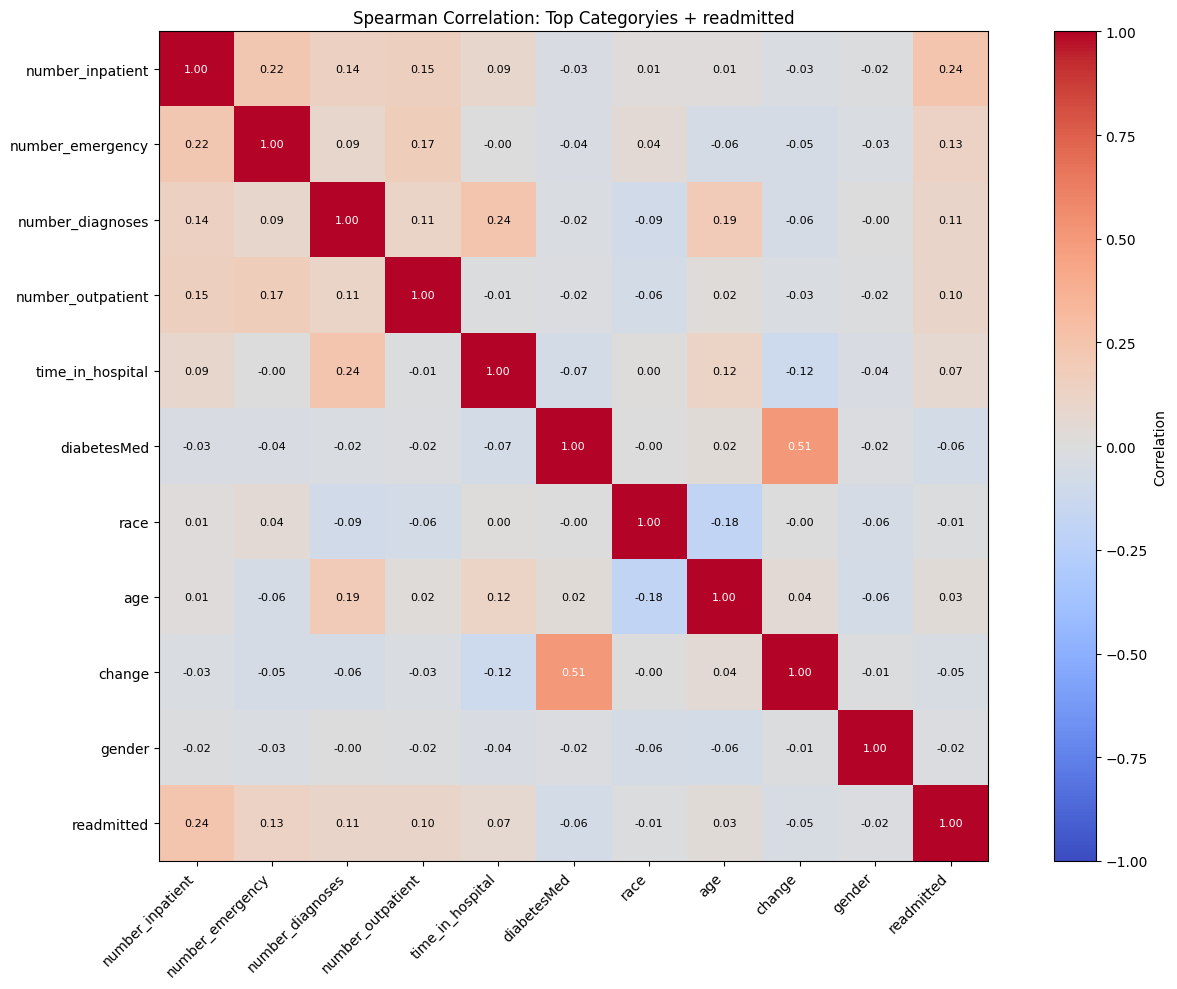

Features in graph: ['number_inpatient', 'number_emergency', 'number_diagnoses', 'number_outpatient', 'time_in_hospital', 'diabetesMed', 'race', 'age', 'change', 'gender', 'readmitted']
Encoding used: age [0-10)=0, [10-20)=1, ...; gender Female=0, Male=1; race Caucasian=0, AfricanAmerican=1, Hispanic=2, Asian=3, Other=4
Correlation with readmitted:
readmitted           1.000000
number_inpatient     0.238223
number_emergency     0.125474
number_diagnoses     0.105370
number_outpatient    0.104701
time_in_hospital     0.065381
age                  0.025944
race                -0.013442
gender              -0.016687
change              -0.046443
diabetesMed         -0.063659


In [91]:
# Correlation heatmap for the top recommended category-like features
import matplotlib.pyplot as plt
from pandas.api.types import is_object_dtype, is_string_dtype
from pandas import CategoricalDtype

target = 'readmitted'

# Ensure _id columns are not used in this stage
raw_df = raw_df[[c for c in raw_df.columns if not c.endswith('_id')]]

# Use the filtered recommendation table from the previous cell
# and explicitly include age, gender, race
top_features = rec['feature'].head(10).tolist()
top_features = [f for f in top_features if f != 'insulin']
if 'change' in raw_df.columns and 'change' not in top_features:
    top_features.append('change')
top_features = top_features[:10]

manual_features = ['age', 'gender', 'race']
selected_features = top_features + manual_features
selected_features = list(dict.fromkeys([f for f in selected_features if f in raw_df.columns and f != target and f != 'payer_code']))

plot_cols = selected_features + [target]

corr_df = raw_df[plot_cols].copy()

# Explicit mappings requested
# age: [0-10)=0, [10-20)=1, ...
age_lower = corr_df['age'].astype(str).str.extract(r'\[(\d+)-', expand=False)
corr_df['age'] = pd.to_numeric(age_lower, errors='coerce') // 10

# gender: Female=0, Male=1
gender_map = {'Female': 0, 'Male': 1}
corr_df['gender'] = corr_df['gender'].map(gender_map)

# race: White/Caucasian=0, Black/AfricanAmerican=1, Hispanic=2, Asian=3, Other=4
race_map = {
    'Caucasian': 0,
    'AfricanAmerican': 1,
    'Hispanic': 2,
    'Asian': 3,
    'Other': 4,
}
corr_df['race'] = corr_df['race'].map(race_map)

# Encode remaining categories to numeric codes for correlation
for col in corr_df.columns:
    if col in ['age', 'gender', 'race']:
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
        corr_df[col] = corr_df[col].fillna(corr_df[col].median())
        continue

    if is_object_dtype(corr_df[col]) or is_string_dtype(corr_df[col]) or isinstance(corr_df[col].dtype, CategoricalDtype):
        corr_df[col] = pd.factorize(corr_df[col].fillna('__MISSING__').astype(str))[0]
    else:
        corr_df[col] = pd.to_numeric(corr_df[col], errors='coerce')
        if corr_df[col].isna().all():
            corr_df[col] = pd.factorize(raw_df[col].fillna('__MISSING__').astype(str))[0]
        else:
            corr_df[col] = corr_df[col].fillna(corr_df[col].median())

corr_matrix = corr_df.corr(method='spearman')

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)

# Add numeric labels to each heatmap square
for i in range(len(corr_matrix.index)):
    for j in range(len(corr_matrix.columns)):
        value = corr_matrix.iloc[i, j]
        text_color = 'white' if abs(value) >= 0.5 else 'black'
        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=text_color, fontsize=8)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha='right')
ax.set_yticklabels(corr_matrix.index)
ax.set_title('Spearman Correlation: Top Categoryies + readmitted')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Correlation')

plt.tight_layout()
plt.show()

print('Features in graph:', plot_cols)
print('Encoding used: age [0-10)=0, [10-20)=1, ...; gender Female=0, Male=1; race Caucasian=0, AfricanAmerican=1, Hispanic=2, Asian=3, Other=4')
print('Correlation with readmitted:')
print(corr_matrix['readmitted'].sort_values(ascending=False).to_string())

## Binary target + readmission model
Convert `readmitted` to binary and train a model to predict if a patient is readmitted.

Mapping:
- `0` = not readmitted (`NO`)
- `1` = readmitted (`<30` or `>30`)

In [20]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Always start from raw training data so target values are consistent
model_df = pd.read_csv('data/train.csv')

# Clean placeholder missing values
model_df = model_df.replace(r'^\s*\?\s*$', pd.NA, regex=True)
model_df = model_df.replace(r'^\s*Unknown/Invalid\s*$', pd.NA, regex=True)
model_df = model_df.replace(r'^\s*$', pd.NA, regex=True)

ids_to_null = {
    'admission_type_id': [5, 6, 8],
    'discharge_disposition_id': [18, 25, 26],
    'admission_source_id': [9, 15, 17, 20, 21],
}
for col, bad_codes in ids_to_null.items():
    if col in model_df.columns:
        model_df[col] = model_df[col].replace(bad_codes, pd.NA)

medicine_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
identifier_cols = ['id', 'encounter_id', 'patient_nbr']
id_code_cols = [col for col in model_df.columns if col.endswith('_id')]

drop_cols = [
    *identifier_cols,
    *id_code_cols,
    'payer_code',
    'medical_specialty',
    'weight',
    *medicine_cols,
]
model_df = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])

# Binary target: no -> 0, <30/>30 -> 1
model_df['readmitted_clean'] = model_df['readmitted'].astype(str).str.strip().str.lower()
target_map = {'no': 0, '<30': 1, '>30': 1}
model_df['readmitted_binary'] = model_df['readmitted_clean'].map(target_map)

# Keep only rows with valid target mapping
model_df = model_df.dropna(subset=['readmitted_binary']).copy()
model_df['readmitted_binary'] = model_df['readmitted_binary'].astype(int)

X = model_df.drop(columns=['readmitted', 'readmitted_clean', 'readmitted_binary'])
y = model_df['readmitted_binary']

categorical_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(exclude=['object', 'category', 'string']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))]), numeric_cols),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), categorical_cols),
    ]
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight='balanced_subsample',
    n_jobs=-1,
)

clf = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print('Target distribution (0=not readmitted, 1=readmitted):')
print(y.value_counts(normalize=True).sort_index().rename('share').to_string())
print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))
print('\nClassification report:')
print(classification_report(y_test, y_pred, digits=4))

y_prob = clf.predict_proba(X_test)[:, 1]
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}')

Target distribution (0=not readmitted, 1=readmitted):
readmitted_binary
0    0.539123
1    0.460877

Confusion matrix:
[[5613 2068]
 [3178 3389]]

Classification report:
              precision    recall  f1-score   support

           0     0.6385    0.7308    0.6815      7681
           1     0.6210    0.5161    0.5637      6567

    accuracy                         0.6318     14248
   macro avg     0.6298    0.6234    0.6226     14248
weighted avg     0.6304    0.6318    0.6272     14248

ROC-AUC: 0.6727


In [19]:
# Quick diagnostic: inspect target labels in the training file
raw_target = pd.read_csv('data/train.csv')['readmitted']
print('Raw readmitted value counts:')
print(raw_target.astype(str).str.strip().value_counts(dropna=False).to_string())

Raw readmitted value counts:
readmitted
No     38405
>30    24881
<30     7950


In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_squared_log_error

# Rebuild cleaned dataset
data = pd.read_csv('data/train.csv')
data = data.replace(r'^\s*\?\s*$', pd.NA, regex=True)
data = data.replace(r'^\s*Unknown/Invalid\s*$', pd.NA, regex=True)
data = data.replace(r'^\s*$', pd.NA, regex=True)

ids_to_null = {
    'admission_type_id': [5, 6, 8],
    'discharge_disposition_id': [18, 25, 26],
    'admission_source_id': [9, 15, 17, 20, 21],
}
for col, bad_codes in ids_to_null.items():
    if col in data.columns:
        data[col] = data[col].replace(bad_codes, pd.NA)

medicine_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
identifier_cols = ['id', 'encounter_id', 'patient_nbr']
id_code_cols = [c for c in data.columns if c.endswith('_id')]

drop_cols = [
    *identifier_cols,
    *id_code_cols,
    'payer_code',
    'medical_specialty',
    'weight',
    *medicine_cols,
]
data = data.drop(columns=[c for c in drop_cols if c in data.columns])

# Binary target: 0 = not readmitted, 1 = readmitted
data['readmitted_binary'] = data['readmitted'].astype(str).str.strip().str.lower().map({'no': 0, '<30': 1, '>30': 1})
data = data.dropna(subset=['readmitted_binary']).copy()
data['readmitted_binary'] = data['readmitted_binary'].astype(int)

X = data.drop(columns=['readmitted', 'readmitted_binary'])
y = data['readmitted_binary']

cat_cols = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object', 'category', 'string']).columns.tolist()

preprocess = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42)
}

rows = []
for name, estimator in models.items():
    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', estimator)
    ])
    pipe.fit(X_train, y_train)

    if name == 'Logistic Regression':
        y_pred_cont = pipe.predict_proba(X_test)[:, 1]
    else:
        y_pred_cont = pipe.predict(X_test)

    y_pred_nonneg = np.clip(y_pred_cont, 0, None)

    r2 = r2_score(y_test, y_pred_cont)
    mae = mean_absolute_error(y_test, y_pred_cont)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_cont))
    rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred_nonneg))

    rows.append({
        'Model': name,
        'R2': r2,
        'MAE': mae,
        'RMSE': rmse,
        'RMSLE': rmsle,
    })

metrics_table = pd.DataFrame(rows).sort_values('RMSE')
print(metrics_table.to_string(index=False, float_format=lambda x: f'{x:.6f}'))

                  Model       R2      MAE     RMSE    RMSLE
    Logistic Regression 0.086394 0.449263 0.476451 0.334337
      Linear Regression 0.062795 0.455061 0.482565 0.337953
Random Forest Regressor 0.061841 0.436676 0.482810 0.337231


/Users/oskarhellgren/Intro-ML-project/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


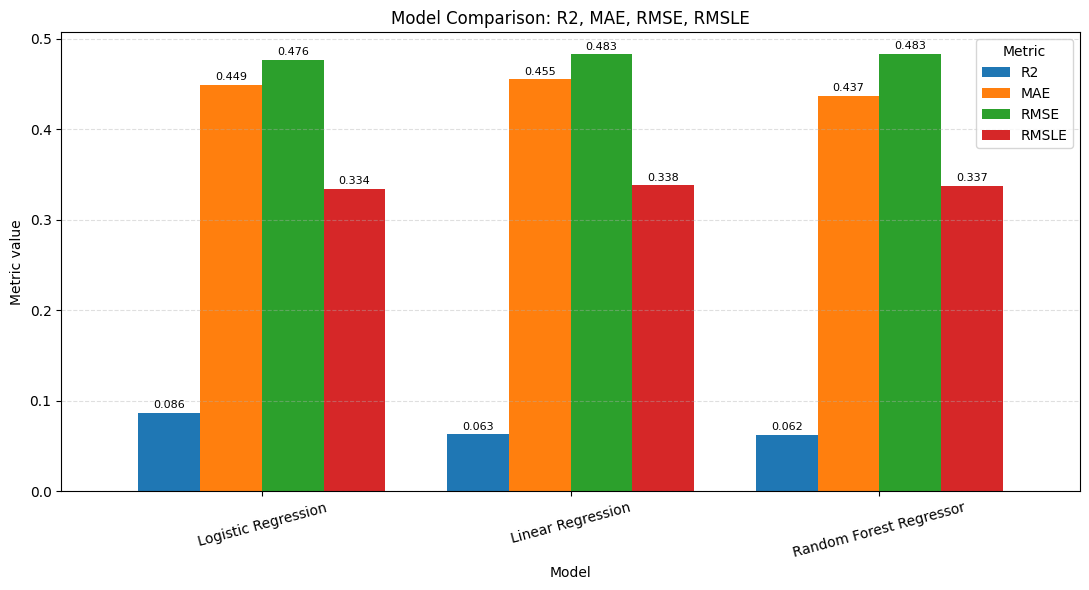

In [23]:
import matplotlib.pyplot as plt

plot_df = metrics_table.copy()
plot_df = plot_df.set_index('Model')[['R2', 'MAE', 'RMSE', 'RMSLE']]

ax = plot_df.plot(kind='bar', figsize=(11, 6), width=0.8)
ax.set_title('Model Comparison: R2, MAE, RMSE, RMSLE')
ax.set_xlabel('Model')
ax.set_ylabel('Metric value')
ax.legend(title='Metric')
ax.tick_params(axis='x', rotation=15)
ax.grid(axis='y', linestyle='--', alpha=0.4)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)

plt.tight_layout()
plt.show()

In [24]:
from sklearn.metrics import roc_auc_score, average_precision_score

roc_auc_value = roc_auc_score(y_test, y_prob)
pr_auc_value = average_precision_score(y_test, y_prob)

print(f'ROC-AUC: {roc_auc_value:.4f}')
print(f'PR-AUC: {pr_auc_value:.4f}')

ROC-AUC: 0.6727
PR-AUC: 0.6391


Best threshold by F1:
  threshold=0.3167, F1=0.6466, precision=0.5071, recall=0.8920

Threshold for recall >= 0.80 (highest precision among valid):
  threshold=0.3700, precision=0.5335, recall=0.8025, F1=0.6409


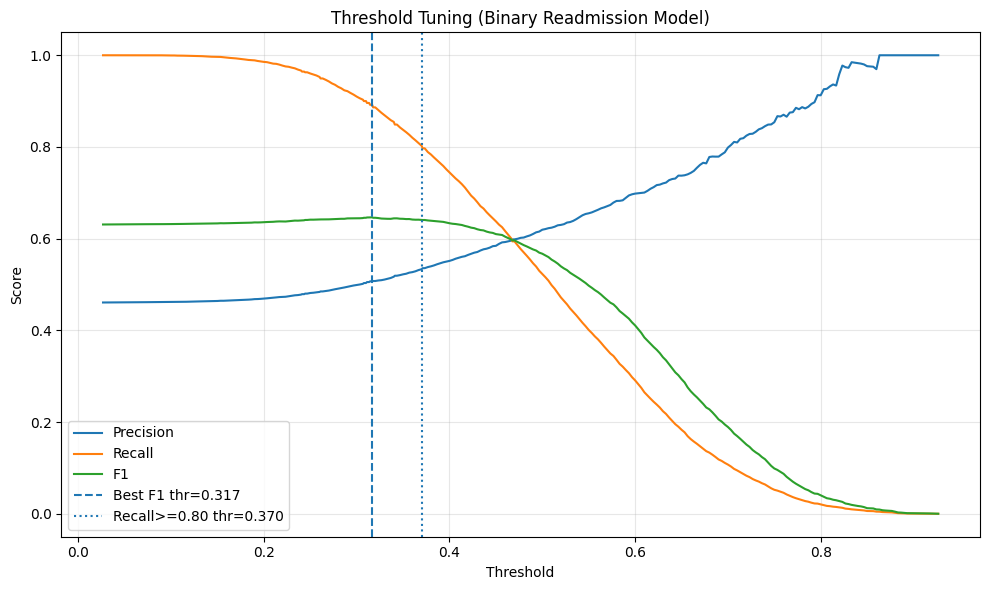

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

# Threshold tuning from existing model outputs: y_test and y_prob
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# precision_recall_curve returns one extra precision/recall point vs thresholds
prec_t = precision[:-1]
rec_t = recall[:-1]

# Avoid divide-by-zero
f1_scores = np.where((prec_t + rec_t) > 0, 2 * prec_t * rec_t / (prec_t + rec_t), 0)

# 1) Best threshold by F1
best_idx = int(np.argmax(f1_scores))
best_thr = float(thresholds[best_idx])
best_f1 = float(f1_scores[best_idx])

# 2) Threshold with recall >= target (choose one with highest precision)
target_recall = 0.80
valid_idx = np.where(rec_t >= target_recall)[0]

if len(valid_idx) > 0:
    best_prec_idx = valid_idx[np.argmax(prec_t[valid_idx])]
    recall_thr = float(thresholds[best_prec_idx])
    recall_prec = float(prec_t[best_prec_idx])
    recall_rec = float(rec_t[best_prec_idx])
else:
    recall_thr = None
    recall_prec = None
    recall_rec = None

# Evaluate both thresholds on hard predictions
y_pred_best_f1 = (y_prob >= best_thr).astype(int)
print('Best threshold by F1:')
print(f'  threshold={best_thr:.4f}, F1={best_f1:.4f}, precision={precision_score(y_test, y_pred_best_f1):.4f}, recall={recall_score(y_test, y_pred_best_f1):.4f}')

if recall_thr is not None:
    y_pred_target_rec = (y_prob >= recall_thr).astype(int)
    print(f'\nThreshold for recall >= {target_recall:.2f} (highest precision among valid):')
    print(f'  threshold={recall_thr:.4f}, precision={recall_prec:.4f}, recall={recall_rec:.4f}, F1={f1_score(y_test, y_pred_target_rec):.4f}')
else:
    print(f'\nNo threshold reached recall >= {target_recall:.2f}.')

# Plot Precision/Recall/F1 vs threshold
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, prec_t, label='Precision')
ax.plot(thresholds, rec_t, label='Recall')
ax.plot(thresholds, f1_scores, label='F1')
ax.axvline(best_thr, linestyle='--', linewidth=1.5, label=f'Best F1 thr={best_thr:.3f}')
if recall_thr is not None:
    ax.axvline(recall_thr, linestyle=':', linewidth=1.5, label=f'Recall>=0.80 thr={recall_thr:.3f}')

ax.set_title('Threshold Tuning (Binary Readmission Model)')
ax.set_xlabel('Threshold')
ax.set_ylabel('Score')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

In [26]:
# Final model training based on ROC/PR + threshold tuning
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)


def build_binary_dataset(path='data/train.csv'):
    data = pd.read_csv(path)
    data = data.replace(r'^\s*\?\s*$', pd.NA, regex=True)
    data = data.replace(r'^\s*Unknown/Invalid\s*$', pd.NA, regex=True)
    data = data.replace(r'^\s*$', pd.NA, regex=True)

    ids_to_null_local = {
        'admission_type_id': [5, 6, 8],
        'discharge_disposition_id': [18, 25, 26],
        'admission_source_id': [9, 15, 17, 20, 21],
    }
    for col, bad_codes in ids_to_null_local.items():
        if col in data.columns:
            data[col] = data[col].replace(bad_codes, pd.NA)

    medicine_cols_local = [
        'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
        'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
        'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
        'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
        'glipizide-metformin', 'glimepiride-pioglitazone',
        'metformin-rosiglitazone', 'metformin-pioglitazone'
    ]
    identifier_cols_local = ['id', 'encounter_id', 'patient_nbr']
    id_code_cols_local = [c for c in data.columns if c.endswith('_id')]

    drop_cols_local = [
        *identifier_cols_local,
        *id_code_cols_local,
        'payer_code',
        'medical_specialty',
        'weight',
        *medicine_cols_local,
    ]
    data = data.drop(columns=[c for c in drop_cols_local if c in data.columns])

    data['readmitted_binary'] = data['readmitted'].astype(str).str.strip().str.lower().map({'no': 0, '<30': 1, '>30': 1})
    data = data.dropna(subset=['readmitted_binary']).copy()
    data['readmitted_binary'] = data['readmitted_binary'].astype(int)

    X_local = data.drop(columns=['readmitted', 'readmitted_binary'])
    y_local = data['readmitted_binary']
    return X_local, y_local


X_all, y_all = build_binary_dataset('data/train.csv')

# Split into train/validation/test = 60/20/20
X_temp, X_test_final, y_temp, y_test_final = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
X_train_final, X_val_final, y_train_final, y_val_final = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

cat_cols_final = X_train_final.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
num_cols_final = X_train_final.select_dtypes(exclude=['object', 'category', 'string']).columns.tolist()

preprocess_final = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols_final),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore'))
        ]), cat_cols_final),
    ]
)

final_model = Pipeline([
    ('preprocess', preprocess_final),
    ('model', RandomForestClassifier(
        n_estimators=400,
        random_state=42,
        class_weight='balanced_subsample',
        n_jobs=-1,
    ))
])

final_model.fit(X_train_final, y_train_final)

# Tune threshold on validation set
val_prob = final_model.predict_proba(X_val_final)[:, 1]
precision_v, recall_v, thresholds_v = precision_recall_curve(y_val_final, val_prob)
prec_t_v = precision_v[:-1]
rec_t_v = recall_v[:-1]
f1_v = np.where((prec_t_v + rec_t_v) > 0, 2 * prec_t_v * rec_t_v / (prec_t_v + rec_t_v), 0)

best_f1_idx = int(np.argmax(f1_v))
threshold_best_f1 = float(thresholds_v[best_f1_idx])

target_recall = 0.80
valid_idx = np.where(rec_t_v >= target_recall)[0]
if len(valid_idx) > 0:
    idx_target = valid_idx[np.argmax(prec_t_v[valid_idx])]
    threshold_target_recall = float(thresholds_v[idx_target])
else:
    threshold_target_recall = threshold_best_f1

# Evaluate on untouched test set
test_prob = final_model.predict_proba(X_test_final)[:, 1]
def evaluate_at_threshold(thr, name):
    y_hat = (test_prob >= thr).astype(int)
    print(f'\n{name} (threshold={thr:.4f})')
    print(f'Precision: {precision_score(y_test_final, y_hat):.4f}')
    print(f'Recall:    {recall_score(y_test_final, y_hat):.4f}')
    print(f'F1:        {f1_score(y_test_final, y_hat):.4f}')
    print('Confusion matrix:')
    print(confusion_matrix(y_test_final, y_hat))

print('Final model: RandomForestClassifier (binary readmission)')
print(f'ROC-AUC (test): {roc_auc_score(y_test_final, test_prob):.4f}')
print(f'PR-AUC  (test): {average_precision_score(y_test_final, test_prob):.4f}')

evaluate_at_threshold(0.5, 'Default threshold')
evaluate_at_threshold(threshold_best_f1, 'Best-F1 threshold from validation')
evaluate_at_threshold(threshold_target_recall, 'Recall-focused threshold from validation')

# Keep for later notebook cells
final_threshold = threshold_target_recall
final_test_prob = test_prob
final_y_test = y_test_final

Final model: RandomForestClassifier (binary readmission)
ROC-AUC (test): 0.6706
PR-AUC  (test): 0.6370

Default threshold (threshold=0.5000)
Precision: 0.6193
Recall:    0.5130
F1:        0.5612
Confusion matrix:
[[5610 2071]
 [3198 3369]]

Best-F1 threshold from validation (threshold=0.3425)
Precision: 0.5167
Recall:    0.8473
F1:        0.6419
Confusion matrix:
[[2476 5205]
 [1003 5564]]

Recall-focused threshold from validation (threshold=0.3750)
Precision: 0.5346
Recall:    0.7911
F1:        0.6380
Confusion matrix:
[[3159 4522]
 [1372 5195]]


In [28]:
# Predict on non-training test file and export results
import pandas as pd

input_path = 'data/non_training_data/test_github.csv'
output_path = 'data/non_training_data/test_github_predictions.csv'

infer_df = pd.read_csv(input_path)

# Preserve identifiers for output if present
id_cols = [c for c in ['id', 'encounter_id', 'patient_nbr'] if c in infer_df.columns]
output_df = infer_df[id_cols].copy() if id_cols else pd.DataFrame(index=infer_df.index)

# Apply same cleaning rules as training
infer_df = infer_df.replace(r'^\s*\?\s*$', pd.NA, regex=True)
infer_df = infer_df.replace(r'^\s*Unknown/Invalid\s*$', pd.NA, regex=True)
infer_df = infer_df.replace(r'^\s*$', pd.NA, regex=True)

ids_to_null_local = {
    'admission_type_id': [5, 6, 8],
    'discharge_disposition_id': [18, 25, 26],
    'admission_source_id': [9, 15, 17, 20, 21],
}
for col, bad_codes in ids_to_null_local.items():
    if col in infer_df.columns:
        infer_df[col] = infer_df[col].replace(bad_codes, pd.NA)

medicine_cols_local = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride',
    'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone',
    'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide',
    'examide', 'citoglipton', 'insulin', 'glyburide-metformin',
    'glipizide-metformin', 'glimepiride-pioglitazone',
    'metformin-rosiglitazone', 'metformin-pioglitazone'
]
identifier_cols_local = ['id', 'encounter_id', 'patient_nbr']
id_code_cols_local = [c for c in infer_df.columns if c.endswith('_id')]

drop_cols_local = [
    *identifier_cols_local,
    *id_code_cols_local,
    'payer_code',
    'medical_specialty',
    'weight',
    *medicine_cols_local,
    'readmitted',
    'readmitted_binary',
]
X_infer = infer_df.drop(columns=[c for c in drop_cols_local if c in infer_df.columns])

# Score using trained final model and threshold
pred_prob = final_model.predict_proba(X_infer)[:, 1]
pred_label = (pred_prob >= final_threshold).astype(int)

output_df['readmitted_probability'] = pred_prob
output_df['readmitted_prediction'] = pred_label
output_df.to_csv(output_path, index=False)

print(f'Saved predictions: {output_path}')
print(output_df.head().to_string(index=False))

Saved predictions: data/non_training_data/test_github_predictions.csv
   id  encounter_id  patient_nbr  readmitted_probability  readmitted_prediction
84364     265783944     43109325                  0.5225                      1
55883     161004840    100467954                  0.5075                      1
85290     269994186    110521260                  0.4450                      1
49990     150606318     47946168                  0.6050                      1
29089      95180010     25359894                  0.5000                      1


In [32]:
# Full guess breakdown on held-out test set + correct guess percentage
import pandas as pd
from sklearn.metrics import accuracy_score

# Use final model outputs from the final training cell
breakdown_df = pd.DataFrame({
    'actual_outcome': final_y_test.reset_index(drop=True),
    'predicted_probability': pd.Series(final_test_prob).reset_index(drop=True),
})
breakdown_df['predicted_outcome'] = (breakdown_df['predicted_probability'] >= final_threshold).astype(int)
breakdown_df['is_correct'] = (breakdown_df['predicted_outcome'] == breakdown_df['actual_outcome'])

correct_pct = accuracy_score(breakdown_df['actual_outcome'], breakdown_df['predicted_outcome']) * 100

print(f'Total guesses: {len(breakdown_df)}')
print(f'Correct guesses: {breakdown_df["is_correct"].sum()}')
print(f'Correct guess percentage: {correct_pct:.2f}%')

print('\nBreakdown by actual outcome:')
print((
    breakdown_df.groupby('actual_outcome')['is_correct']
    .agg(total='count', correct='sum', accuracy='mean')
    .assign(accuracy=lambda d: (d['accuracy'] * 100).round(2))
    .rename(columns={'accuracy': 'accuracy_pct'})
    .to_string()
))

breakdown_output_path = 'data/test_guess_breakdown.csv'
breakdown_df.to_csv(breakdown_output_path, index=False)
print(f'\nSaved full per-row breakdown to: {breakdown_output_path}')
print('\nFirst 10 rows:')
print(breakdown_df.head(10).to_string(index=False))
print(classification_report(final_y_test, breakdown_df['predicted_outcome'], digits=4))

Total guesses: 14248
Correct guesses: 8354
Correct guess percentage: 58.63%

Breakdown by actual outcome:
                total  correct  accuracy_pct
actual_outcome                              
0                7681     3159         41.13
1                6567     5195         79.11

Saved full per-row breakdown to: data/test_guess_breakdown.csv

First 10 rows:
 actual_outcome  predicted_probability  predicted_outcome  is_correct
              1                 0.6325                  1        True
              1                 0.2900                  0       False
              1                 0.3500                  0       False
              0                 0.5025                  1       False
              1                 0.5300                  1        True
              1                 0.4950                  1        True
              1                 0.2850                  0       False
              0                 0.3650                  0        True
    